# Preprocessing Pipeline 視覺化

逐步展示 `SkinAnalysisPipeline` 的每個處理階段與中間結果。

**處理流程：**
1. 載入原始輸入
2. 遮罩垂直膨脹 (`dilate_epidermis_vertically`)
3. 背景校正 (`BackgroundCorrection`)
4. Sato 管狀增強（可選）
5. 區域正規化 (`regional_minmax_normalize` / `regional_clahe_normalize`)
6. Pseudo-label 生成 (`multi_otsu_threshold`)
7. Annotation 合併 (OR)
8. 形態學開運算 → 最終 Label

In [29]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from neural_reconstruction.core.preprocessing.pipeline import SkinAnalysisPipeline
from neural_reconstruction.core.preprocessing.config import (
    PipelineConfig, MorphologyConfig, MaskConfig, BackgroundConfig,
    ThresholdConfig, NormalizationConfig,
)
from neural_reconstruction.core.preprocessing.mask_operations import (
    dilate_epidermis_vertically, apply_mask, invert_mask,
)
from neural_reconstruction.core.preprocessing.background_correction import BackgroundCorrection
from neural_reconstruction.core.preprocessing.thresholding import multi_otsu_threshold
from neural_reconstruction.core.preprocessing.utils import (
    regional_minmax_normalize, regional_clahe_normalize,
)
from neural_reconstruction.core.preprocessing.morphology import morphological_opening

def show(*args, figsize=None, cmap='viridis', suptitle=None):
    """顯示多張影像。
    用法: show((img1, title1), (img2, title2), ...)
    """
    # 每個 arg 都是 (ndarray, str) tuple
    pairs = list(args)
    n = len(pairs)
    if figsize is None:
        figsize = (6 , 5 * n)
    fig, axes = plt.subplots(n, 1, figsize=figsize, constrained_layout=True)
    if n == 1:
        axes = [axes]
    for ax, (img, title) in zip(axes, pairs):
        ax.imshow(img, cmap=cmap if img.ndim == 2 else None)
        ax.set_title(title, fontsize=11)
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    plt.show()

## 1. 載入原始輸入

image      shape: (2867, 5632), dtype: uint8
mask       shape: (2867, 5632), dtype: uint8
annotation shape: (2867, 5632), dtype: uint8


/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36664 (\N{CJK UNIFIED IDEOGRAPH-8F38}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


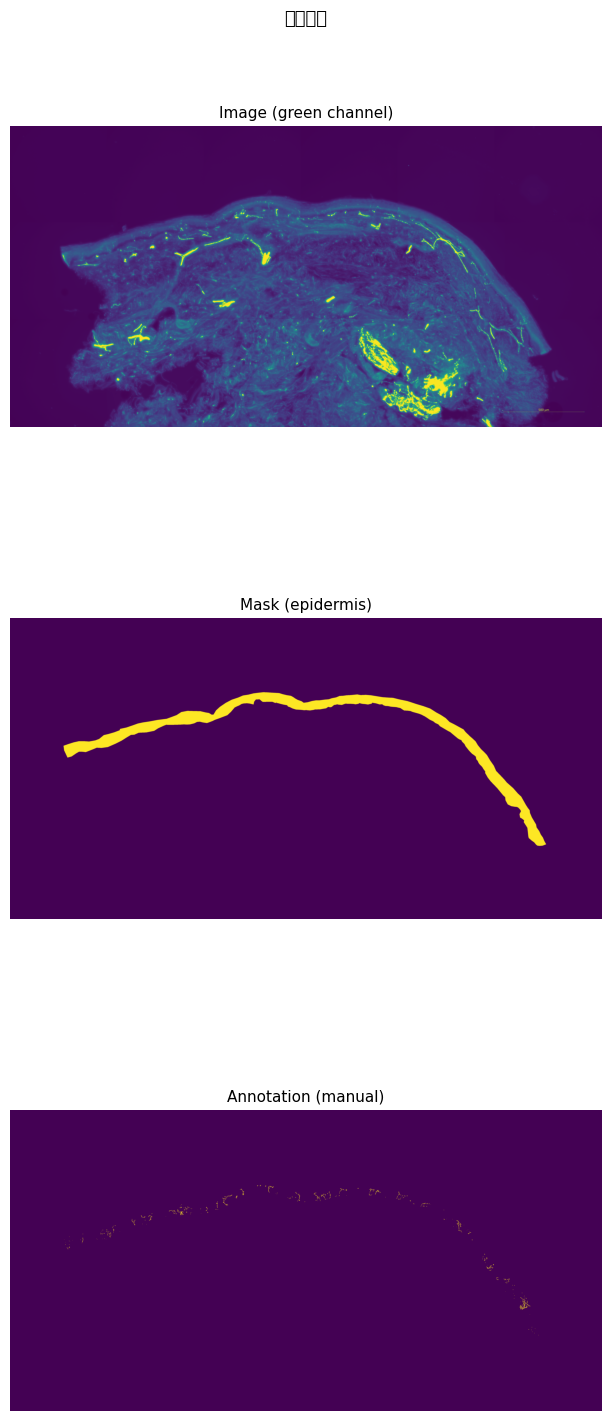

In [41]:
IMAGE_ID  = 'S1585-2_a'
BASE_PATH = f'../data/{IMAGE_ID}'

image      = cv2.imread(f'{BASE_PATH}/image.png',      cv2.IMREAD_COLOR_RGB)[:, :, 1]  # 只取綠色通道s
mask       = cv2.imread(f'{BASE_PATH}/mask.png',       cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(f'{BASE_PATH}/annotation.png', cv2.IMREAD_GRAYSCALE)

print(f'image      shape: {image.shape}, dtype: {image.dtype}')
print(f'mask       shape: {mask.shape}, dtype: {mask.dtype}')
print(f'annotation shape: {annotation.shape}, dtype: {annotation.dtype}')

show(
    (image,      'Image (green channel)'),
    (mask,       'Mask (epidermis)'),
    (annotation, 'Annotation (manual)'),
    suptitle='原始輸入'
)

## 2. 參數設定

In [42]:
config = PipelineConfig(
    morphology=MorphologyConfig(
        opening_kernel=3,
    ),
    mask=MaskConfig(
        dilate_offset=100,
    ),
    background=BackgroundConfig(
        method='rolling_ball',
        radius=4,
        sato_weight=0.0,       # 0 = 停用；0~1 = Sato blend 比例
        sato_sigmas=(1.0, 2.0),
    ),
    threshold=ThresholdConfig(
        use_full_roi=False,    # False = 只對 dermis ROI 閾值化
    ),
    normalization=NormalizationConfig(
        enabled=True,
        method='minmax',       # 'minmax' 或 'clahe'
        clip_limit=2.0,
        tile_grid_size=(8, 8),
    ),
)

print(config)

PipelineConfig(morphology=MorphologyConfig(closing_kernel=3, opening_kernel=3), mask=MaskConfig(dilate_offset=100), background=BackgroundConfig(method='rolling_ball', radius=4, sato_weight=0.0, sato_sigmas=(1.0, 2.0)), threshold=ThresholdConfig(use_full_roi=False), normalization=NormalizationConfig(enabled=True, method='minmax', clip_limit=2.0, tile_grid_size=(8, 8)))


## 3. Step 1 — 遮罩垂直膨脹

`dilate_epidermis_vertically(mask, offset_px)` 將表皮遮罩向下延伸，以涵蓋穿越邊界的神經纖維。
真皮 ROI = `dilated_mask AND (NOT epidermis_mask)`

/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36974 (\N{CJK UNIFIED IDEOGRAPH-906E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32617 (\N{CJK UNIFIED IDEOGRAPH-7F69}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33192 (\N{CJK UNIFIED IDEOGRAPH-81A8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33081 (\N{CJK UNIFIED IDEOGRAPH-8139}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py

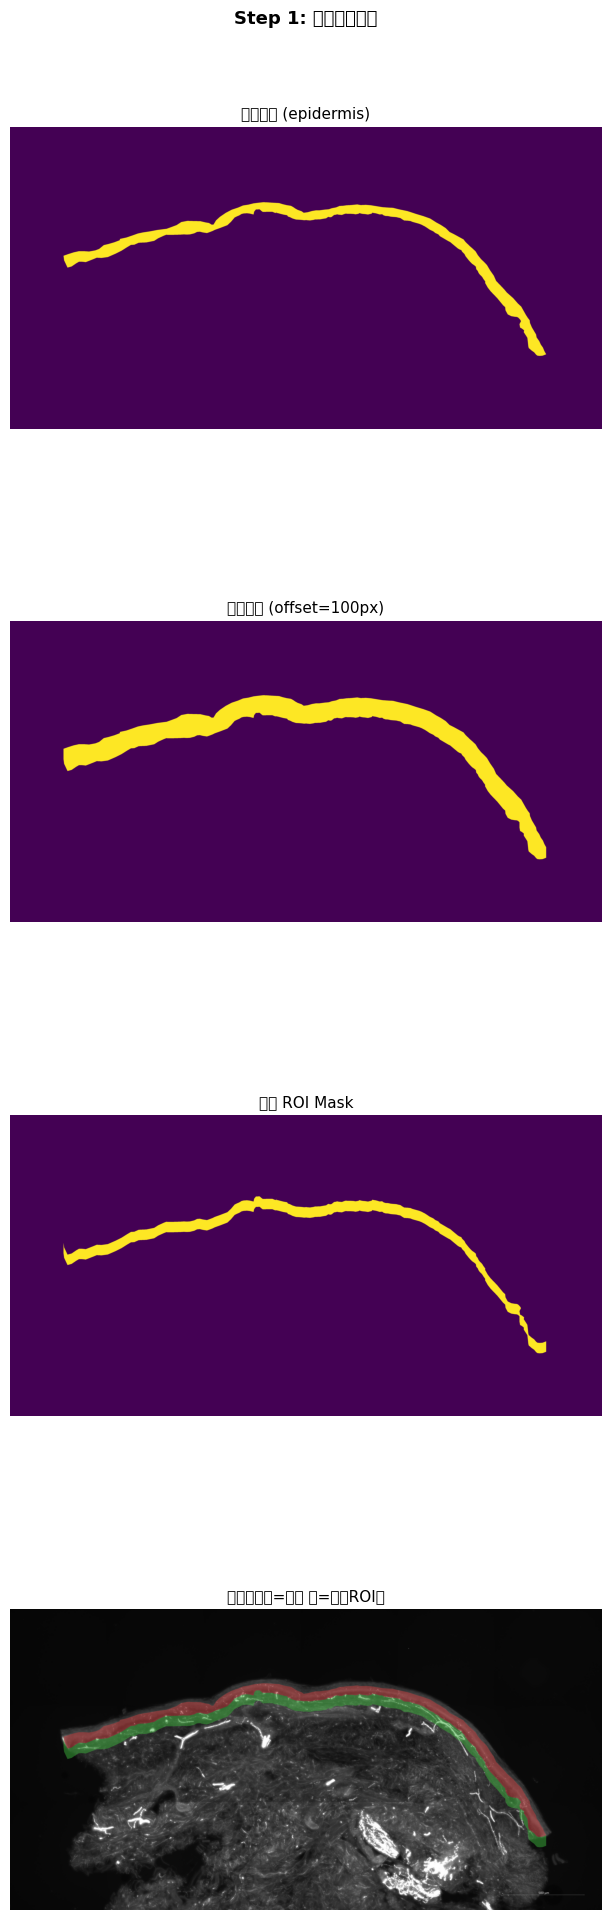

In [43]:
dilated_mask = dilate_epidermis_vertically(mask, offset_px=config.mask.dilate_offset)

# 真皮 ROI = 膨脹遮罩 AND NOT 表皮遮罩
inverted_epidermis = invert_mask(mask)
dermis_roi_mask    = apply_mask(dilated_mask, inverted_epidermis)

# 合成視覺化：同時標示表皮（紅）和真皮 ROI（綠）
overlay = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
overlay[mask > 0]          = (overlay[mask > 0] * 0.5 + np.array([200, 60, 60]) * 0.5).astype(np.uint8)
overlay[dermis_roi_mask > 0] = (overlay[dermis_roi_mask > 0] * 0.5 + np.array([60, 180, 60]) * 0.5).astype(np.uint8)

show(
    (mask,            f'原始遮罩 (epidermis)'),
    (dilated_mask,    f'膨脹遮罩 (offset={config.mask.dilate_offset}px)'),
    (dermis_roi_mask, '真皮 ROI Mask'),
    (overlay,         '疊合圖（紅=表皮 綠=真皮ROI）'),
    suptitle='Step 1: 遮罩垂直膨脹'
)

## 4. Step 2 — 背景校正

`BackgroundCorrection` 估計背景亮度並相減，移除不均勻照明。
支援 `rolling_ball` 和 `morphology` 兩種方式。

/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20272 (\N{CJK UNIFIED IDEOGRAPH-4F30}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35336 (\N{CJK UNIFIED IDEOGRAPH-8A08}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py

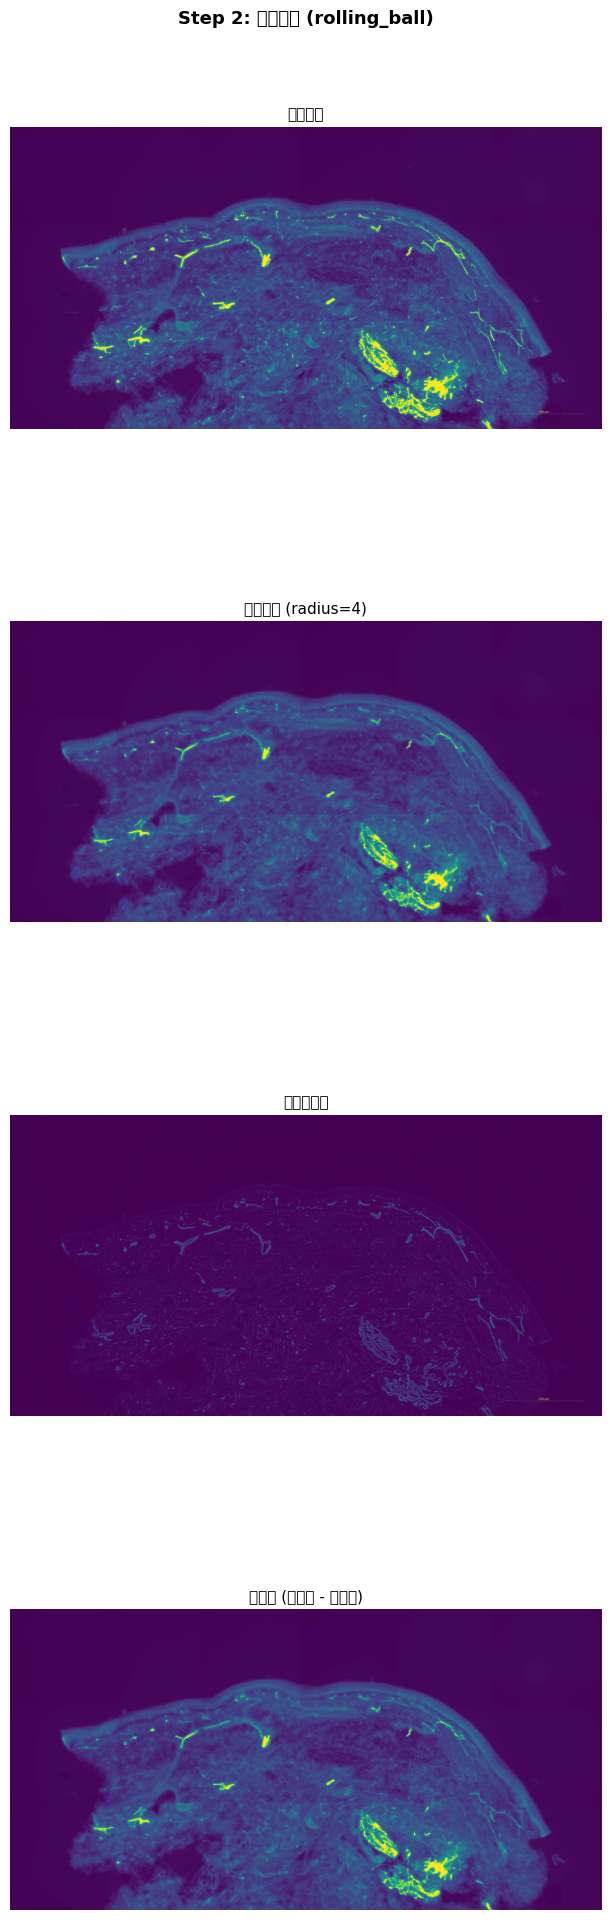

原始影像  — mean: 36.4, std: 37.5
校正後影像 — mean: 3.4, std: 8.9


In [44]:
corrector = BackgroundCorrection(
    method=config.background.method,
    radius=config.background.radius,
    sato_weight=0.0,  # 先不加 sato，下一步單獨展示
    sato_sigmas=config.background.sato_sigmas,
)

# 手動取得 background 估計圖
from skimage.restoration import rolling_ball
background = rolling_ball(image, radius=config.background.radius).astype(np.uint8)
corrected  = cv2.subtract(image, background)

# 差值圖：校正前後差異
diff = cv2.absdiff(image, corrected)

show(
    (image,      '原始影像'),
    (background, f'估計背景 (radius={config.background.radius})'),
    (corrected,  '背景校正後'),
    (diff,       '差異圖 (校正前 - 校正後)'),
    suptitle=f'Step 2: 背景校正 ({config.background.method})'
)

print(f'原始影像  — mean: {image.mean():.1f}, std: {image.std():.1f}')
print(f'校正後影像 — mean: {corrected.mean():.1f}, std: {corrected.std():.1f}')

## 5. Step 3 — Sato 管狀增強（可選）

`sato()` 強調管狀/纖維狀結構。`sato_weight` 控制混合比例：
- `0.0`：完全不套用
- `1.0`：完全替換
- 介於 0~1：與背景校正結果線性混合

/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31649 (\N{CJK UNIFIED IDEOGRAPH-7BA1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29376 (\N{CJK UNIFIED IDEOGRAPH-72C0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24375 (\N{CJK UNIFIED IDEOGRAPH-5F37}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


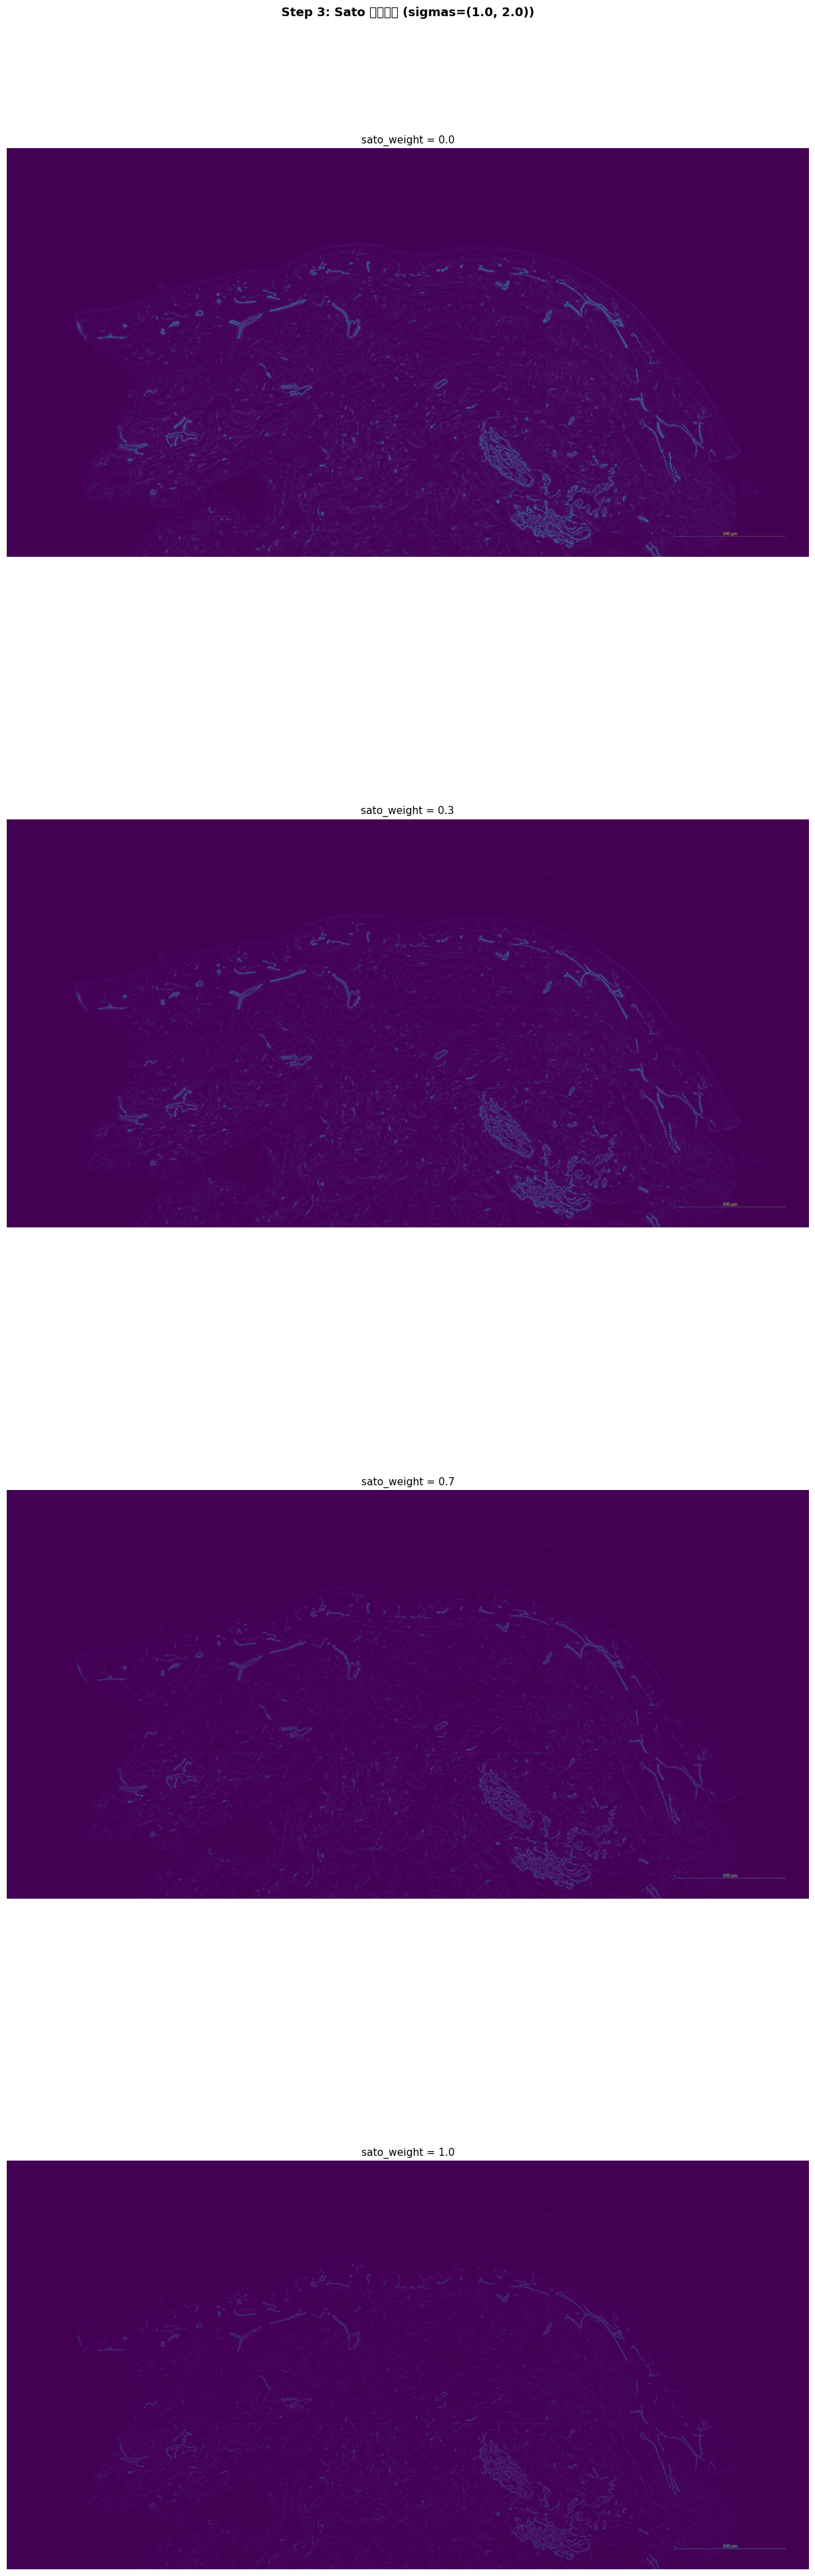

sato_weight=0，不套用 Sato 增強


In [45]:
from skimage.filters import sato

# 計算 sato 結果
sato_raw = sato(
    corrected.astype(np.float32),
    sigmas=config.background.sato_sigmas,
    black_ridges=False,
    mode='reflect',
)
s_min, s_max = sato_raw.min(), sato_raw.max()
sato_norm = ((sato_raw - s_min) / (s_max - s_min + 1e-8) * 255).astype(np.uint8)

# 不同 blend weight 的效果
fig, axes = plt.subplots(4, 1, figsize=(12, 40), constrained_layout=True)
for ax, w in zip(axes, [0.0, 0.3, 0.7, 1.0]):
    blended = np.clip(
        (1 - w) * corrected.astype(np.float32) + w * sato_norm.astype(np.float32), 0, 255
    ).astype(np.uint8)
    ax.imshow(blended)
    ax.set_title(f'sato_weight = {w}', fontsize=11)
    ax.axis('off')
fig.suptitle(f'Step 3: Sato 管狀增強 (sigmas={config.background.sato_sigmas})', fontsize=13, fontweight='bold')
plt.show()

# 套用設定中的 weight
if config.background.sato_weight > 0:
    corrected = np.clip(
        (1 - config.background.sato_weight) * corrected.astype(np.float32)
        + config.background.sato_weight * sato_norm.astype(np.float32),
        0, 255,
    ).astype(np.uint8)
    print(f'已套用 sato_weight={config.background.sato_weight}')
else:
    print('sato_weight=0，不套用 Sato 增強')

## 6. Step 4 — 區域正規化

對**表皮**和**真皮**區域分別獨立正規化，避免不同區域亮度差異影響後續閾值化。
- `minmax`：線性拉伸到 0-255
- `clahe`：自適應對比度增強

/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35215 (\N{CJK UNIFIED IDEOGRAPH-898F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21312 (\N{CJK UNIFIED IDEOGRAPH-5340}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22495 (\N{CJK UNIFIED IDEOGRAPH-57DF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py

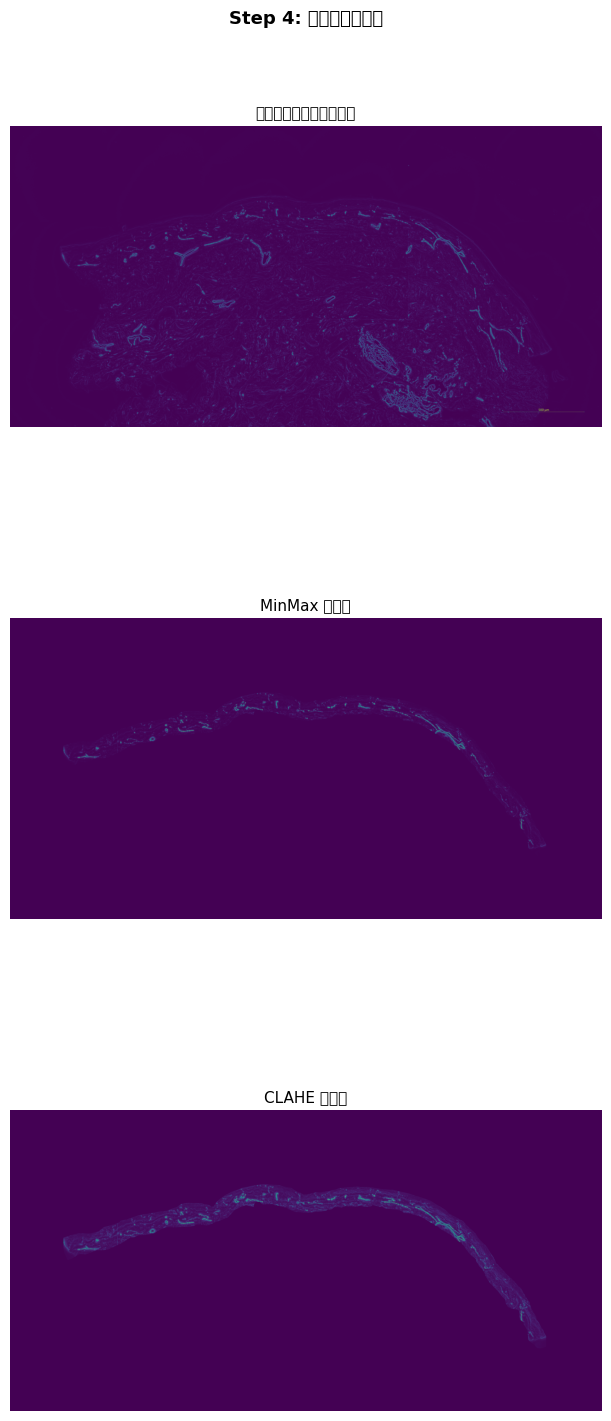

正規化方式: minmax


In [46]:
corrected_minmax = regional_minmax_normalize(
    corrected, epidermis_mask=mask, dermis_mask=dermis_roi_mask
)
corrected_clahe = regional_clahe_normalize(
    corrected,
    epidermis_mask=mask,
    dermis_mask=dermis_roi_mask,
    clip_limit=config.normalization.clip_limit,
    tile_grid_size=config.normalization.tile_grid_size,
)

# 套用設定中選定的方式
if config.normalization.enabled:
    if config.normalization.method == 'clahe':
        corrected_normalized = corrected_clahe
    else:
        corrected_normalized = corrected_minmax
else:
    corrected_normalized = corrected

show(
    (corrected,            '正規化前（背景校正後）'),
    (corrected_minmax,     'MinMax 正規化'),
    (corrected_clahe,      'CLAHE 正規化'),
    suptitle='Step 4: 區域正規化比較'
)

print(f'正規化方式: {config.normalization.method if config.normalization.enabled else "disabled"}')

## 7. Step 5 — Pseudo-label 生成 (Multi-Otsu Thresholding)

`multi_otsu_threshold` 將影像分為多個強度等級，取最亮等級作為纖維。

- `use_full_roi=False`：只對真皮 ROI 遮罩區域閾值化
- `use_full_roi=True`：對整個 ROI 影像閾值化

/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35009 (\N{CJK UNIFIED IDEOGRAPH-88C1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


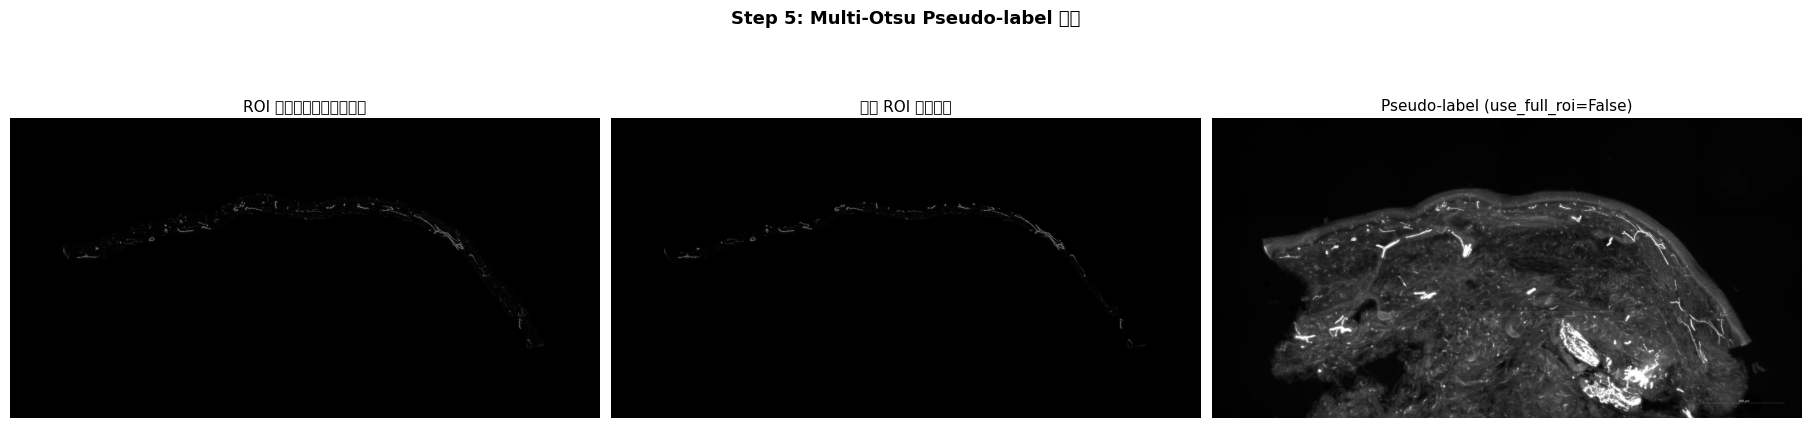

/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21482 (\N{CJK UNIFIED IDEOGRAPH-53EA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20491 (\N{CJK UNIFIED IDEOGRAPH-500B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


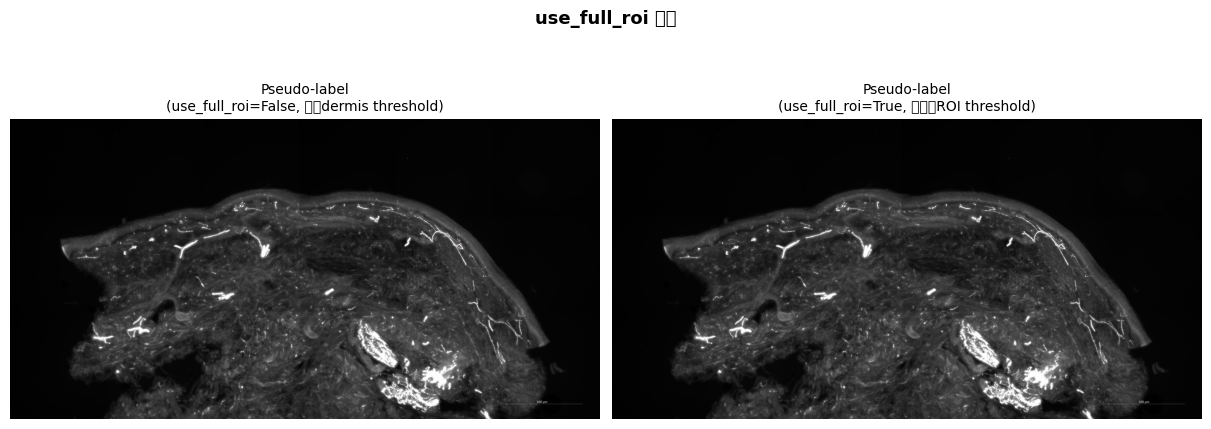

使用: use_full_roi=False
Pseudo-label 正像素數: 23955


In [47]:
from skimage.filters import threshold_multiotsu

# ROI 影像 = 正規化後以膨脹遮罩裁切
roi_image = apply_mask(corrected_normalized, dilated_mask)

# 只對真皮 ROI 遮罩區域閾值化
masked_region_only = apply_mask(corrected_normalized, dermis_roi_mask)
pseudo_label_dermis = multi_otsu_threshold(masked_region_only)

# 對整個 ROI 閾值化
pseudo_label_full = multi_otsu_threshold(roi_image)

# 視覺化閾值分佈
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

axes[0].imshow(roi_image, cmap='gray')
axes[0].set_title('ROI 影像（膨脹遮罩裁切）', fontsize=11)
axes[0].axis('off')

axes[1].imshow(masked_region_only, cmap='gray')
axes[1].set_title('真皮 ROI 遮罩區域', fontsize=11)
axes[1].axis('off')

axes[2].imshow(image, cmap='gray')
axes[2].imshow(np.ma.masked_where(pseudo_label_dermis == 0, pseudo_label_dermis), cmap='Reds', alpha=0.7)
axes[2].set_title('Pseudo-label (use_full_roi=False)', fontsize=11)
axes[2].axis('off')

fig.suptitle('Step 5: Multi-Otsu Pseudo-label 生成', fontsize=13, fontweight='bold')
plt.show()

# 比較 use_full_roi 的效果
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
axes2[0].imshow(image, cmap='gray')
axes2[0].imshow(np.ma.masked_where(pseudo_label_dermis == 0, pseudo_label_dermis), cmap='Reds', alpha=0.7)
axes2[0].set_title('Pseudo-label\n(use_full_roi=False, 只對dermis threshold)', fontsize=10)
axes2[0].axis('off')

axes2[1].imshow(image, cmap='gray')
axes2[1].imshow(np.ma.masked_where(pseudo_label_full == 0, pseudo_label_full), cmap='Blues', alpha=0.7)
axes2[1].set_title('Pseudo-label\n(use_full_roi=True, 對整個ROI threshold)', fontsize=10)
axes2[1].axis('off')
fig2.suptitle('use_full_roi 比較', fontsize=13, fontweight='bold')
plt.show()

# 取用設定中的方式
pseudo_label = pseudo_label_full if config.threshold.use_full_roi else pseudo_label_dermis
print(f'使用: use_full_roi={config.threshold.use_full_roi}')
print(f'Pseudo-label 正像素數: {(pseudo_label > 0).sum()}')

## 8. Step 6 — Annotation OR Pseudo-label 合併

手動標注（annotation）與自動生成的 pseudo-label 透過 OR 操作合併，
確保手動標注的纖維不會遺失，同時補充自動偵測到的部分。

/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20358 (\N{CJK UNIFIED IDEOGRAPH-4F86}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28304 (\N{CJK UNIFIED IDEOGRAPH-6E90}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py

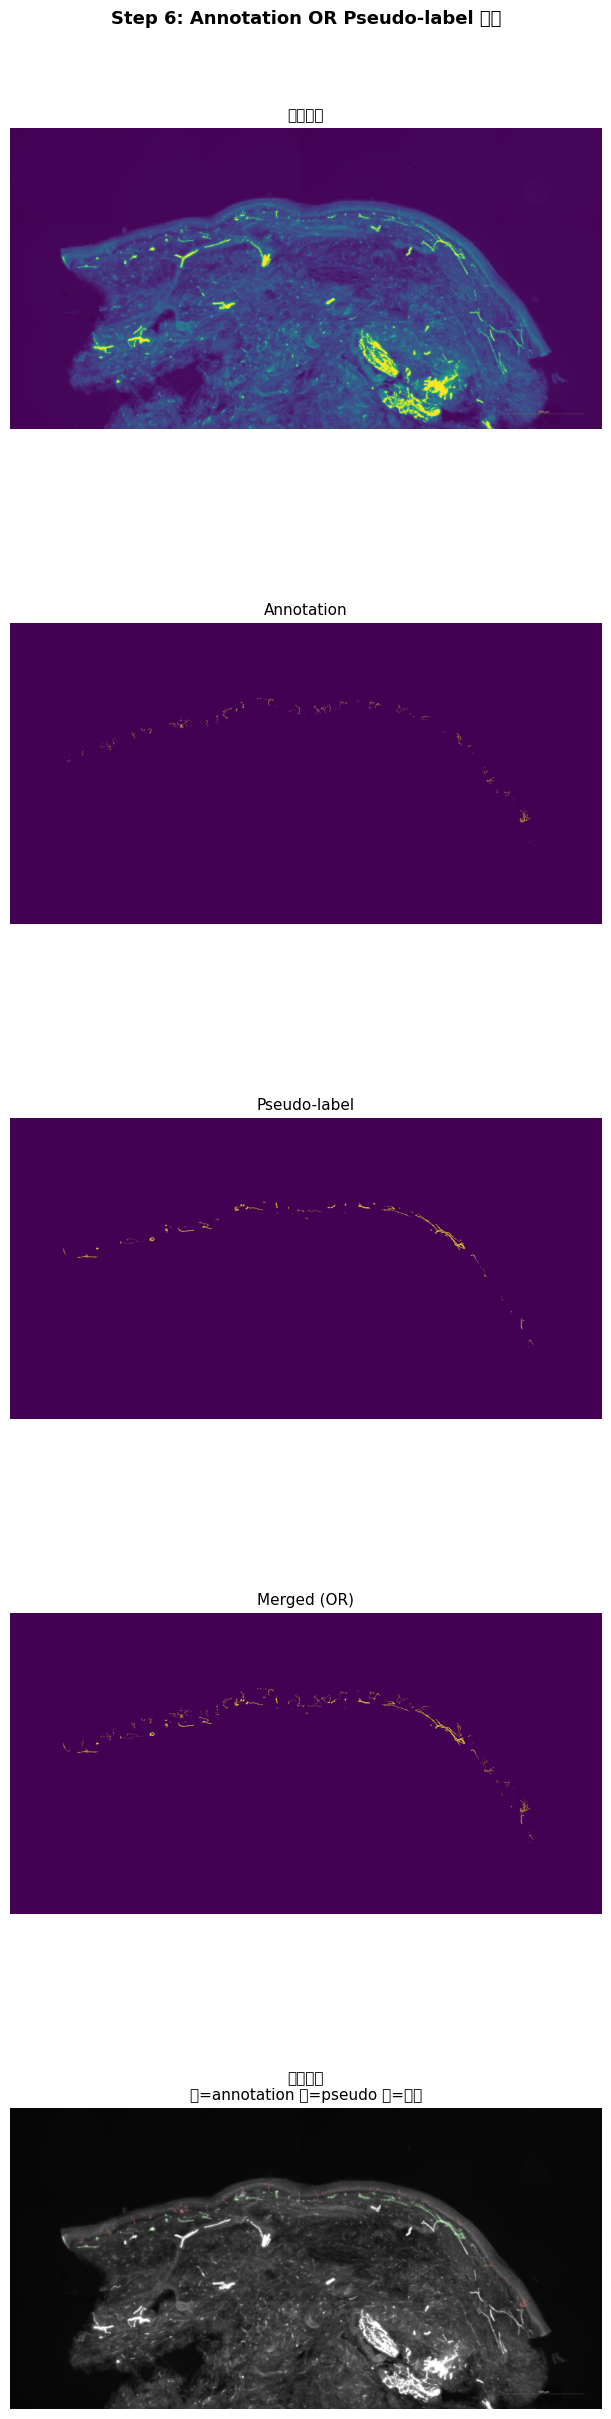

只有 annotation  : 12509 px
只有 pseudo-label: 23955 px
兩者重疊          : 0 px
合併後總計         : 36464 px


In [48]:
from neural_reconstruction.core.preprocessing.mask_operations import combine_masks_or

merged = combine_masks_or(annotation, pseudo_label)

# 分析各來源貢獻
only_annotation  = (annotation > 0) & (pseudo_label == 0)
only_pseudo      = (annotation == 0) & (pseudo_label > 0)
both             = (annotation > 0) & (pseudo_label > 0)

# 彩色合成圖
rgb_merge = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
rgb_merge[only_annotation] = (rgb_merge[only_annotation] * 0.4 + np.array([220, 60, 60])  * 0.6).astype(np.uint8)  # 紅 = 只有annotation
rgb_merge[only_pseudo]     = (rgb_merge[only_pseudo]     * 0.4 + np.array([60,  180, 60]) * 0.6).astype(np.uint8)  # 綠 = 只有pseudo
rgb_merge[both]            = (rgb_merge[both]            * 0.4 + np.array([220, 180, 60]) * 0.6).astype(np.uint8)  # 黃 = 兩者都有

show(
    (image,                         '原始影像'),
    (annotation,                    'Annotation'),
    (pseudo_label,                  'Pseudo-label'),
    (merged,                        'Merged (OR)'),
    (rgb_merge,                     '來源分析\n紅=annotation 綠=pseudo 黃=兩者'),
    suptitle='Step 6: Annotation OR Pseudo-label 合併'
)

print(f'只有 annotation  : {only_annotation.sum()} px')
print(f'只有 pseudo-label: {only_pseudo.sum()} px')
print(f'兩者重疊          : {both.sum()} px')
print(f'合併後總計         : {(merged > 0).sum()} px')

## 9. Step 7 — 形態學開運算（最終 Label）

`morphological_opening` 移除雜訊小點，保留主要纖維結構。
`opening_kernel` 控制去噪力度。

/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38283 (\N{CJK UNIFIED IDEOGRAPH-958B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36939 (\N{CJK UNIFIED IDEOGRAPH-904B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31639 (\N{CJK UNIFIED IDEOGRAPH-7B97}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py

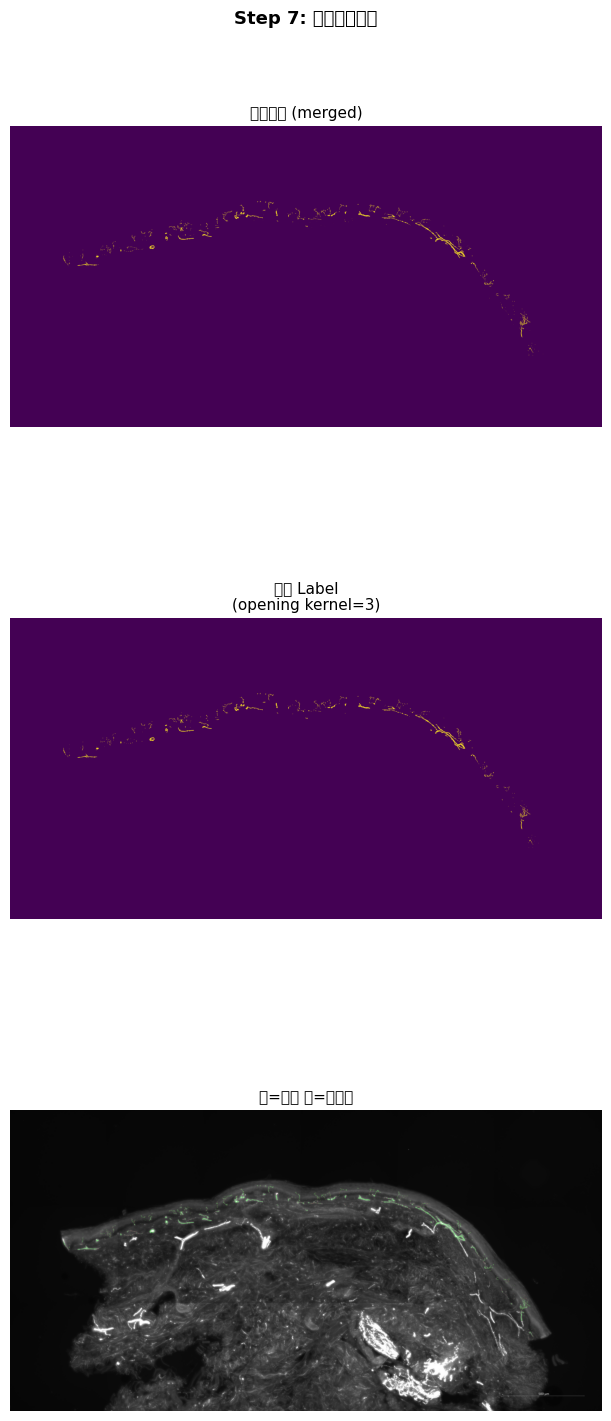

開運算前  : 36464 px
最終 label: 32696 px
移除像素  : 3768 px (10.3%)


In [49]:
final_label = morphological_opening(
    merged,
    kernel_size=config.morphology.opening_kernel,
    kernel_shape='ellipse',
    iterations=1,
)

# 被移除的像素
removed = (merged > 0) & (final_label == 0)

overlay_removed = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
overlay_removed[final_label > 0] = (overlay_removed[final_label > 0] * 0.4 + np.array([60, 200, 60]) * 0.6).astype(np.uint8)
overlay_removed[removed]         = (overlay_removed[removed]         * 0.4 + np.array([220, 60, 60]) * 0.6).astype(np.uint8)

show(
    (merged,           '開運算前 (merged)'),
    (final_label,      f'最終 Label\n(opening kernel={config.morphology.opening_kernel})'),
    (overlay_removed,  f'綠=保留 紅=被移除'),
    suptitle='Step 7: 形態學開運算'
)

print(f'開運算前  : {(merged > 0).sum()} px')
print(f'最終 label: {(final_label > 0).sum()} px')
print(f'移除像素  : {removed.sum()} px ({100*removed.sum()/(merged > 0).sum():.1f}%)')

## 10. 完整流程總覽

/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23436 (\N{CJK UNIFIED IDEOGRAPH-5B8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


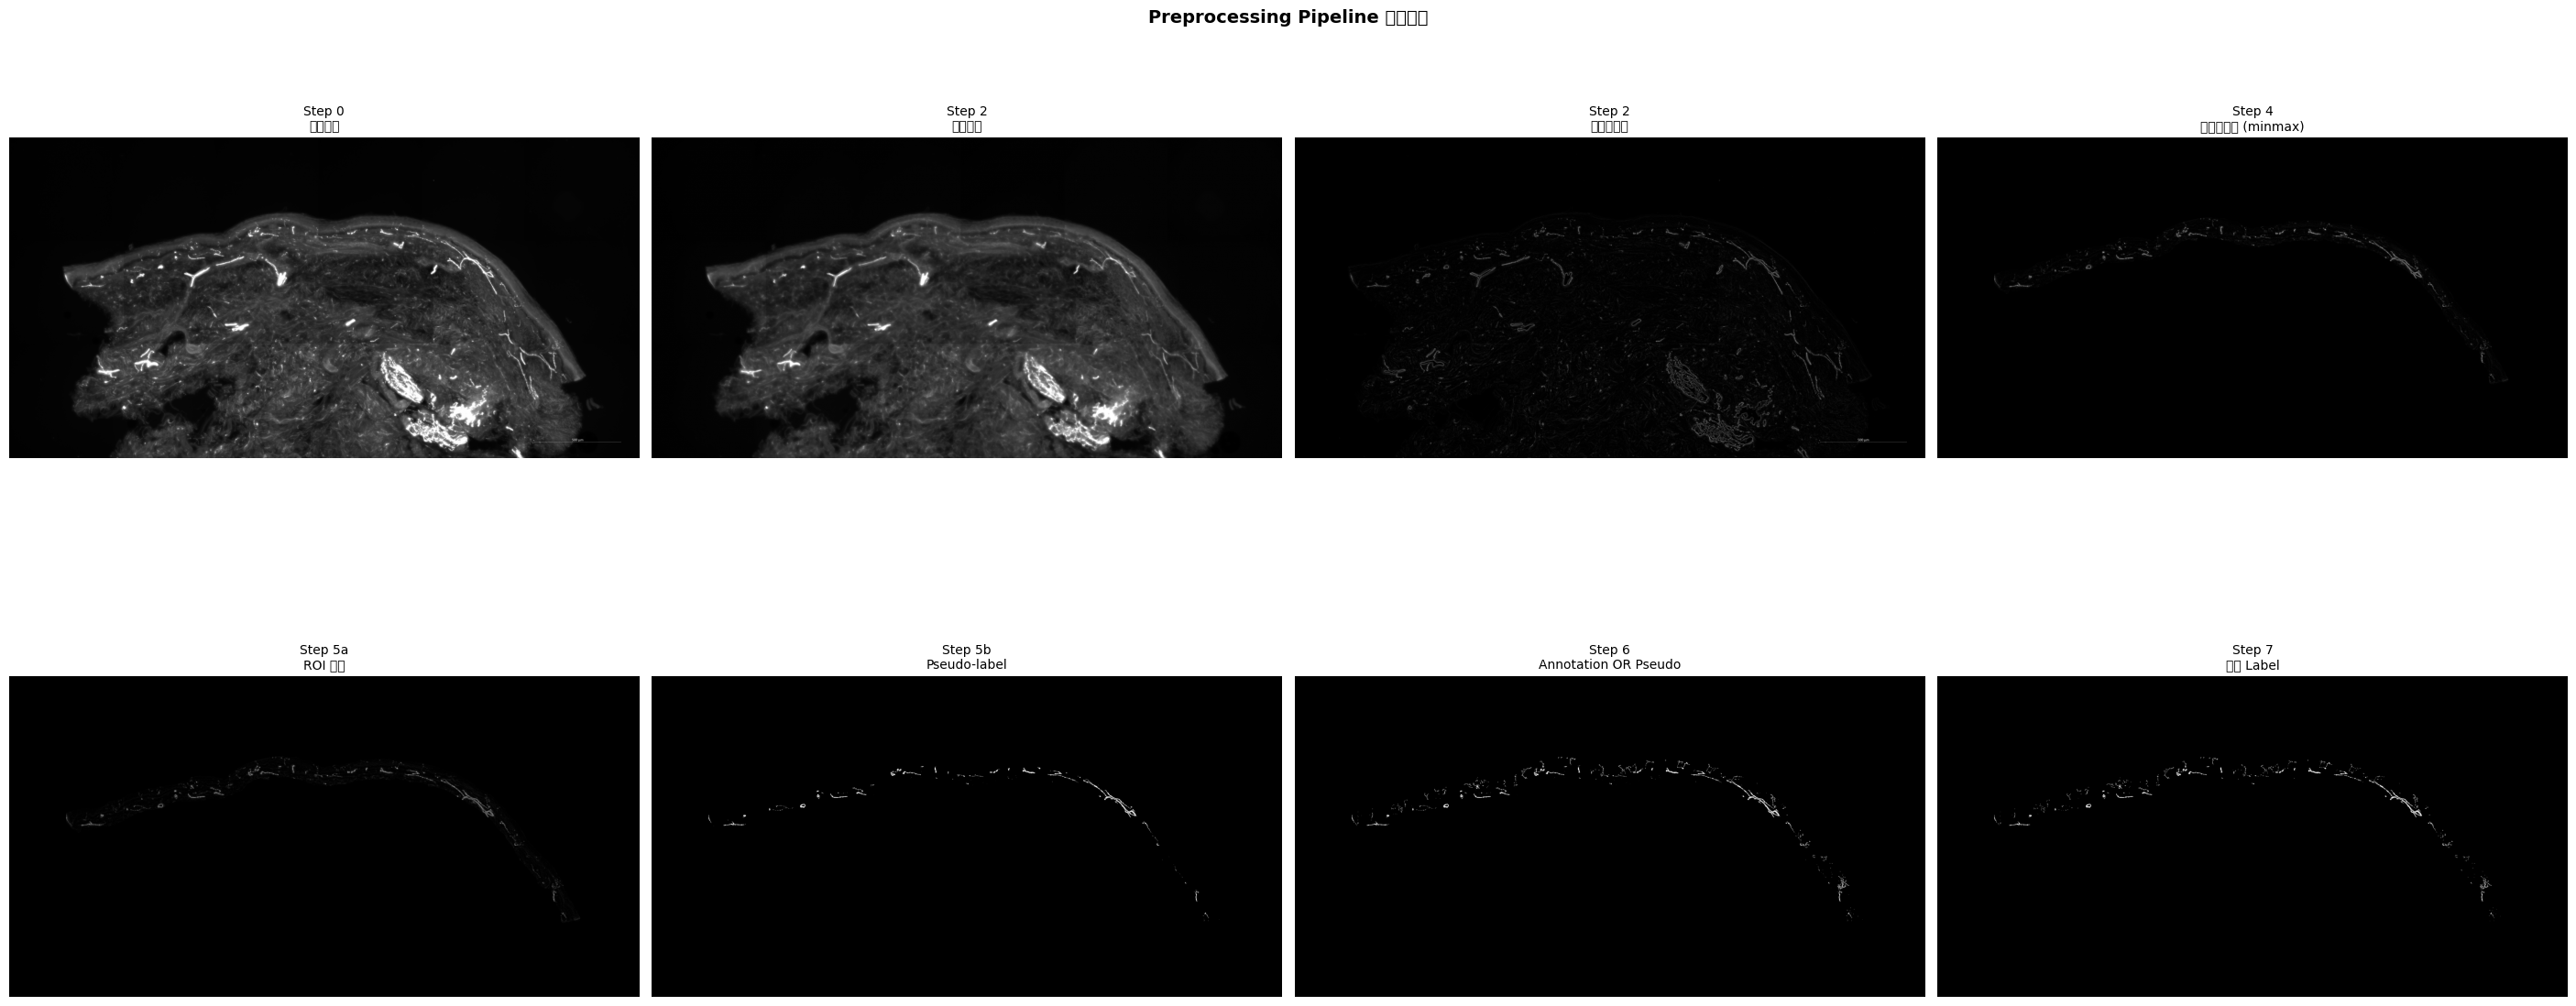

In [50]:
# 使用 SkinAnalysisPipeline 執行完整流程（結果應與上面逐步執行一致）
pipeline = SkinAnalysisPipeline(config)
final_label_pipeline, roi_image_pipeline = pipeline.run(annotation, mask, image)

fig, axes = plt.subplots(2, 4, figsize=(28, 12), constrained_layout=True)

steps = [
    (image,                'Step 0\n原始影像'),
    (background,           f'Step 2\n背景估計'),
    (corrected,            f'Step 2\n背景校正後'),
    (corrected_normalized, f'Step 4\n區域正規化 ({config.normalization.method})'),
    (roi_image,            'Step 5a\nROI 影像'),
    (pseudo_label,         'Step 5b\nPseudo-label'),
    (merged,               'Step 6\nAnnotation OR Pseudo'),
    (final_label,          'Step 7\n最終 Label'),
]

for ax, (img, title) in zip(axes.flat, steps):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.suptitle('Preprocessing Pipeline 完整流程', fontsize=14, fontweight='bold')
plt.show()

## 11. 輸入 vs 輸出 比較

/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 34389 (\N{CJK UNIFIED IDEOGRAPH-8655}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py

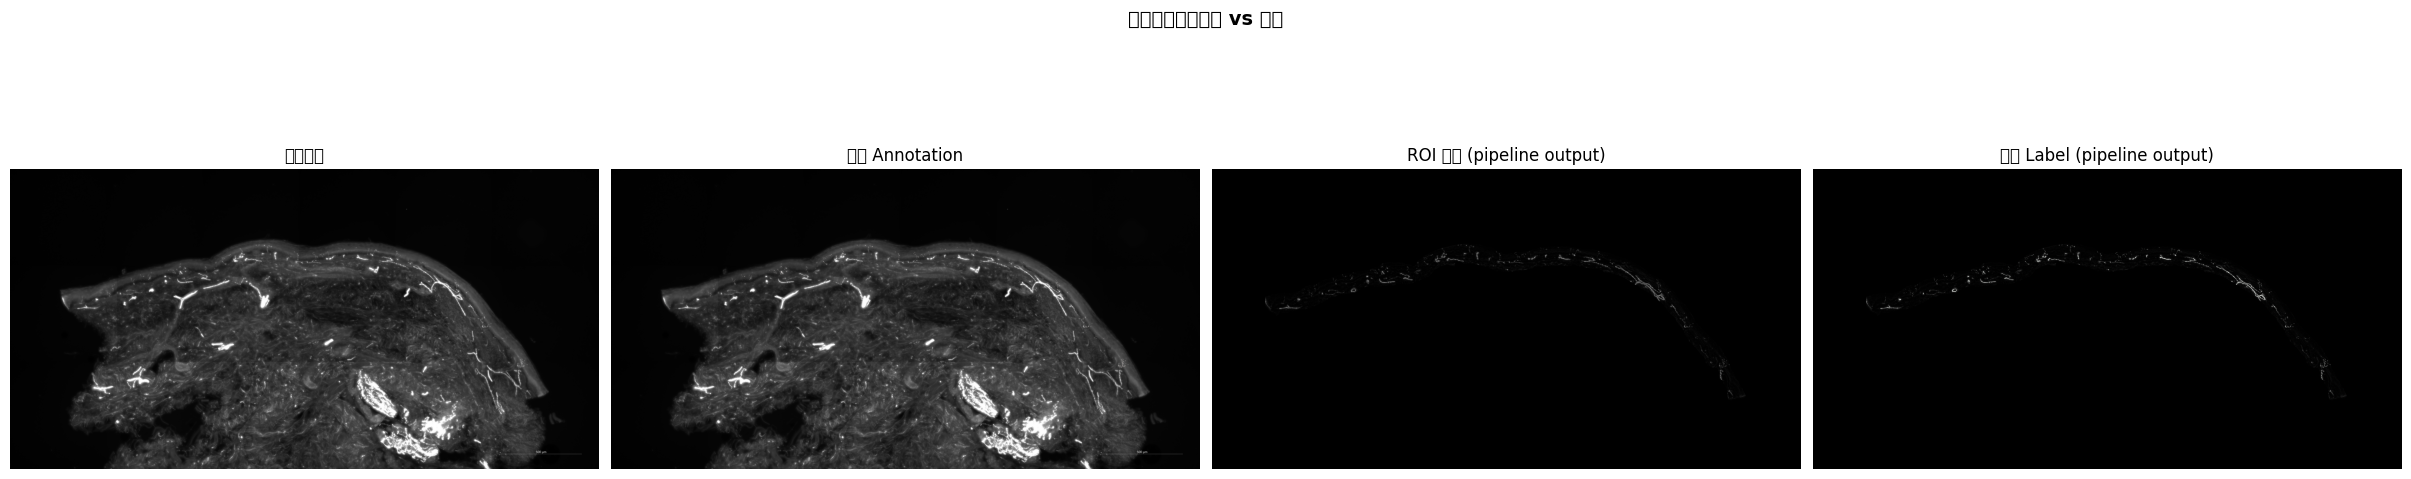

=== 統計 ===
原始 annotation 正像素: 12509
最終 label 正像素:      32696
增長倍數:               2.61x


In [51]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6), constrained_layout=True)

axes[0].imshow(image, cmap='gray')
axes[0].set_title('原始影像', fontsize=12)
axes[0].axis('off')

axes[1].imshow(image, cmap='gray')
axes[1].imshow(np.ma.masked_where(annotation == 0, annotation), cmap='Reds', alpha=0.75)
axes[1].set_title('原始 Annotation', fontsize=12)
axes[1].axis('off')

axes[2].imshow(roi_image_pipeline, cmap='gray')
axes[2].set_title('ROI 影像 (pipeline output)', fontsize=12)
axes[2].axis('off')

axes[3].imshow(roi_image_pipeline, cmap='gray')
axes[3].imshow(np.ma.masked_where(final_label_pipeline == 0, final_label_pipeline), cmap='Greens', alpha=0.75)
axes[3].set_title('最終 Label (pipeline output)', fontsize=12)
axes[3].axis('off')

fig.suptitle('前處理結果：輸入 vs 輸出', fontsize=14, fontweight='bold')
plt.show()

print('=== 統計 ===')
print(f'原始 annotation 正像素: {(annotation > 0).sum()}')
print(f'最終 label 正像素:      {(final_label_pipeline > 0).sum()}')
print(f'增長倍數:               {(final_label_pipeline > 0).sum() / max((annotation > 0).sum(), 1):.2f}x')